In [1]:
import os, math, glob, random
import numpy as np
import tensorflow as tf
import keras
from tensorflow.keras.models import load_model
from PIL import Image
import matplotlib.pyplot as plt



2025-11-04 12:32:08.225642: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762259528.407599      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762259528.461584      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# --- Sampling layer for reparameterization ---
class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        mu, logvar = inputs
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + tf.exp(0.5 * logvar) * eps

# --- Encoder (Conv) ---
def build_encoder(latent_dim=32, img_shape=(28,28,1)):
    inputs = tf.keras.Input(shape=img_shape)
    x = tf.keras.layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(inputs)
    x = tf.keras.layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2D(128, 3, strides=1, padding="same", activation="relu")(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    mu = tf.keras.layers.Dense(latent_dim, name="z_mu")(x)
    logvar = tf.keras.layers.Dense(latent_dim, name="z_logvar")(x)
    z = Sampling()([mu, logvar])
    return tf.keras.Model(inputs, [z, mu, logvar], name="encoder")

# --- Decoder (ConvTranspose) ---
def build_decoder(latent_dim=32):
    latent_inputs = tf.keras.Input(shape=(latent_dim,))
    x = tf.keras.layers.Dense(7*7*128, activation="relu")(latent_inputs)
    x = tf.keras.layers.Reshape((7,7,128))(x)
    x = tf.keras.layers.Conv2DTranspose(128, 3, strides=1, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    outputs = tf.keras.layers.Conv2DTranspose(1, 3, padding="same", activation="sigmoid")(x)
    return tf.keras.Model(latent_inputs, outputs, name="decoder")


In [3]:
@keras.saving.register_keras_serializable(name="ConvBetaVAE")
class ConvBetaVAE(tf.keras.Model):
    def __init__(self, encoder=None, decoder=None, beta_var=None,
                 latent_dim=32, img_shape=(28,28,1), **kwargs):
        super().__init__(**kwargs)
        
        self.encoder = encoder if encoder is not None else build_encoder(latent_dim=latent_dim, img_shape=img_shape)
        self.decoder = decoder if decoder is not None else build_decoder(latent_dim=latent_dim)
        
        self.beta = beta_var if beta_var is not None else tf.Variable(1.0, dtype=tf.float32, trainable=False, name="beta")

        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs, training=False):
        z, mu, logvar = self.encoder(inputs, training=training)
        x_hat = self.decoder(z, training=training)
        return x_hat

    def get_config(self):
        return {"latent_dim": 32, "img_shape": (28,28,1)}

    @classmethod
    def from_config(cls, config):
        latent_dim = config.get("latent_dim", 32)
        img_shape  = tuple(config.get("img_shape", (28,28,1)))
        enc = build_encoder(latent_dim=latent_dim, img_shape=img_shape)
        dec = build_decoder(latent_dim=latent_dim)
        beta = tf.Variable(1.0, dtype=tf.float32, trainable=False, name="beta")
        return cls(encoder=enc, decoder=dec, beta_var=beta,
                   latent_dim=latent_dim, img_shape=img_shape)


In [4]:
def find_file(filename, must_contain=None):
    for root in ["/kaggle/working", "/kaggle/input"]:
        for dp, dn, fn in os.walk(root):
            if must_contain and must_contain not in dp:
                continue
            if filename in fn:
                return os.path.join(dp, filename)
    return None

VAE_PATH = find_file("conv_beta_vae_best.keras", must_contain="risultati-output-vae")
GEN_PATH = find_file("generator_ema.keras", must_contain="risultati-output-gan") or \
           find_file("generator.keras", must_contain="risultati-output-gan")

print("VAE_PATH:", VAE_PATH)
print("GEN_PATH:", GEN_PATH)

assert VAE_PATH, "conv_beta_vae_best.keras doesn't found"
assert GEN_PATH, "generator(.ema).keras doesn't found"

vae_model = load_model(VAE_PATH, custom_objects={"ConvBetaVAE": ConvBetaVAE}, compile=False, safe_mode=False)
gen_model = load_model(GEN_PATH, compile=False, safe_mode=False)

print(" VAE:", type(vae_model))
print(" GEN:", type(gen_model))


VAE_PATH: /kaggle/input/risultati-output-vae/conv_beta_vae_best.keras
GEN_PATH: /kaggle/input/risultati-output-gan/1762246906_finetune_v6_ttur_smooth_ema/generator_ema.keras


I0000 00:00:1762259543.200429      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


 VAE: <class '__main__.ConvBetaVAE'>
 GEN: <class 'keras.src.models.functional.Functional'>


In [ ]:
def get_image_shape_from_vae(vae):
    
    if hasattr(vae, "encoder") and hasattr(vae.encoder, "input_shape"):
        ish = vae.encoder.input_shape
    elif hasattr(vae, "encoder") and hasattr(vae.encoder, "inputs") and vae.encoder.inputs:
        ish = vae.encoder.inputs[0].shape
    else:
        raise RuntimeError("Impossible to perform shape inference")
    
    if isinstance(ish, (list, tuple)) and isinstance(ish[0], (list, tuple)):
        ish = ish[0]
    H, W, C = int(ish[1]), int(ish[2]), int(ish[3])
    return H, W, C

def get_latent_shape_from_generator(gen):
    if hasattr(gen, "inputs") and gen.inputs:
        gish = gen.inputs[0].shape
    elif hasattr(gen, "input_shape"):
        gish = gen.input_shape
    else:
        raise RuntimeError("Impossible to perform shape inference")
    if isinstance(gish, (list, tuple)) and isinstance(gish[0], (list, tuple)):
        gish = gish[0]
    if len(gish) == 2:
        return (int(gish[1]),)
    elif len(gish) == 4:
        return (int(gish[1]), int(gish[2]), int(gish[3]))
    else:
        return tuple(int(x) for x in gish[1:])



In [ ]:
H, W, C = get_image_shape_from_vae(vae_model)
latent_shape = get_latent_shape_from_generator(gen_model)
print(f"VAE input: H={H}, W={W}, C={C}")
print(f"GEN latent shape: {latent_shape}")


BATCH = 8
x = np.random.rand(BATCH, H, W, C).astype("float32")

# VAE
recons = vae_model(x, training=False).numpy()  
print("Recon:", recons.shape, recons.min(), recons.max())

# GEN
if len(latent_shape) == 1:
    z = np.random.randn(BATCH, latent_shape[0]).astype("float32")
else:
    z = np.random.randn(BATCH, *latent_shape).astype("float32")

gen_imgs = gen_model.predict(z, verbose=0)
print("Gen:", gen_imgs.shape, gen_imgs.min(), gen_imgs.max())


VAE input: H=28, W=28, C=1
GEN latent shape: (128,)


I0000 00:00:1762259545.286679      37 cuda_dnn.cc:529] Loaded cuDNN version 90300


Recon: (8, 28, 28, 1) 0.0016324066 0.75849116


I0000 00:00:1762259546.536438      82 service.cc:148] XLA service 0x7c3b54005800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762259546.537134      82 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


Gen: (8, 28, 28, 1) -1.0 0.95255494


I0000 00:00:1762259546.980479      82 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[OK] VAE test: (10000, 28, 28, 1), range [0.000,1.000]
[OK] GAN test: (10000, 28, 28, 1), range [0.000,1.000]


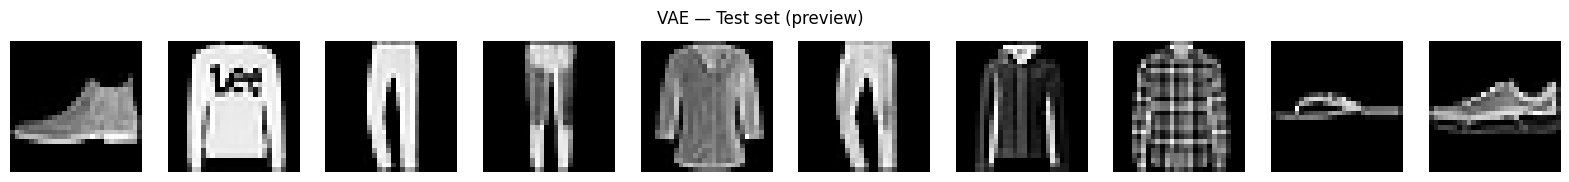

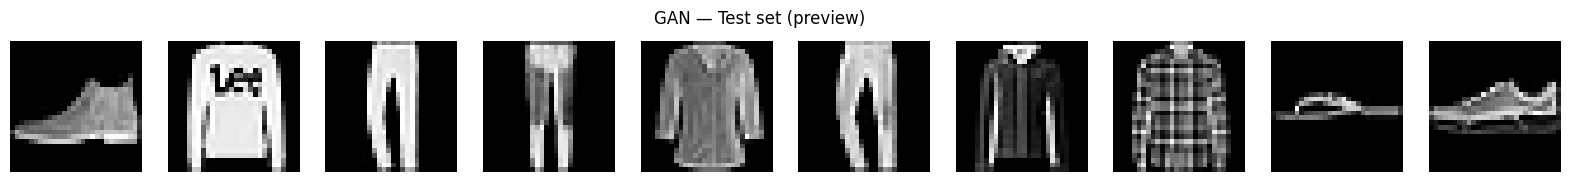

In [ ]:
BASE_DIR = "/kaggle/input/resulteda/output_bundle/datasets"

import os, numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def to01(a):
    a = a.astype("float32")
    if a.max() > 1.0: a = a / 255.0
    if a.min() < 0.0: a = (a + 1.0) / 2.0
    return np.clip(a, 0, 1)

def ensure_hwC(x, H, W, C):
    """
    Converts an image array to shape (N, H, W, C) with dtype float32 and values in [0,1].
    Also handles channel-first inputs (N, C, H, W).
    """
    x = np.asarray(x).astype("float32")

    if x.ndim == 4 and x.shape[1] in (1, 3) and (x.shape[2], x.shape[3]) == (H, W):
        
        x = np.transpose(x, (0, 2, 3, 1))
    elif x.ndim == 3 and x.shape[0] == H and x.shape[1] == W:
        
        x = x[None, ...]
    elif x.ndim == 3 and x.shape[-1] not in (1, 3):
        
        x = x[..., None]
    elif x.ndim == 2:
        
        x = x[None, ..., None]

    if x.max() > 1.0:
        x = x / 255.0
    if x.min() < 0.0:
        x = (x + 1.0) / 2.0
    x = np.clip(x, 0, 1)

    if (x.shape[1], x.shape[2]) != (H, W):
        out = np.empty((x.shape[0], H, W, x.shape[-1]), dtype=np.float32)
        for i in range(x.shape[0]):
            arr = (x[i] * 255).astype("uint8")
            if x.shape[-1] == 1:
                pil = Image.fromarray(arr.squeeze(), mode="L")
            else:
                pil = Image.fromarray(arr, mode="RGB")
            pil = pil.resize((W, H), Image.BICUBIC)
            rr = np.asarray(pil).astype("float32") / 255.0
            if rr.ndim == 2: rr = rr[..., None]
            out[i] = rr
        x = out

    if C == 1 and x.shape[-1] != 1:
        x = x.mean(axis=-1, keepdims=True)
    elif C == 3 and x.shape[-1] == 1:
        x = np.repeat(x, 3, axis=-1)

    return np.clip(x, 0, 1)



def show_row(imgs, title, max_n=10):
    imgs = to01(imgs)
    n = min(max_n, imgs.shape[0])
    plt.figure(figsize=(n*2, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        im = imgs[i]
        if im.shape[-1] == 1: im = im[...,0]
        plt.imshow(im, cmap="gray" if im.ndim==2 else None, vmin=0, vmax=1)
        plt.axis("off")
    plt.suptitle(title); plt.show()

def load_npz_images(path):
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    data = np.load(path)
    
    for k in ["x_test", "images", "x", "arr_0"]:
        if k in data:
            return data[k]
    return data[list(data.keys())[0]]

# ---- path ----
vae_test_path  = os.path.join(BASE_DIR, "fashion_mnist_vae_test.npz")
gan_test_path  = os.path.join(BASE_DIR, "fashion_mnist_gan_test.npz")
vae_train_path = os.path.join(BASE_DIR, "fashion_mnist_vae_train.npz")
gan_train_path = os.path.join(BASE_DIR, "fashion_mnist_gan_train.npz")

# ---- loading ----
raw_vae = load_npz_images(vae_test_path)
raw_gan = load_npz_images(gan_test_path)
x_train_vae = load_npz_images(vae_train_path)
x_train_gan = load_npz_images(gan_train_path)

# ---- normalizze a (N,H,W,C) ----
x_test_vae = ensure_hwC(raw_vae, H, W, C)
x_test_gan = ensure_hwC(raw_gan, H, W, C)

print(f"[OK] VAE test: {x_test_vae.shape}, range [{x_test_vae.min():.3f},{x_test_vae.max():.3f}]")
print(f"[OK] GAN test: {x_test_gan.shape}, range [{x_test_gan.min():.3f},{x_test_gan.max():.3f}]")

# ---- preview ----
show_row(x_test_vae, "VAE — Test set (preview)")
show_row(x_test_gan, "GAN — Test set (preview)")


In [8]:
# === Utility: VAE latent dimension ===
import numpy as np

def get_latent_dim_from_vae(vae):
    """
    Infers the latent dimension from the VAE by inspecting the encoder.
    - Supports encoders that return [z, mu, logvar] or only z.
    """
    H, W, C = get_image_shape_from_vae(vae)
    dummy = np.zeros((1, H, W, C), dtype="float32")
    outs = vae.encoder(dummy, training=False)

    if isinstance(outs, (list, tuple)) and len(outs) >= 2:
        mu = outs[1]
        return int(mu.shape[-1])
    elif isinstance(outs, (list, tuple)) and len(outs) >= 1:
        z = outs[0]
        return int(z.shape[-1])
    elif hasattr(outs, "shape"):
        return int(outs.shape[-1])
    else:
        print("Impossible make latent dim inference")
        return 32


Recon: (8, 28, 28, 1) 5.352253e-21 0.9946688
VAE prior samples: (8, 28, 28, 1) 1.2266186e-16 0.9568227
GAN samples: (8, 28, 28, 1) 0.0 0.99010086


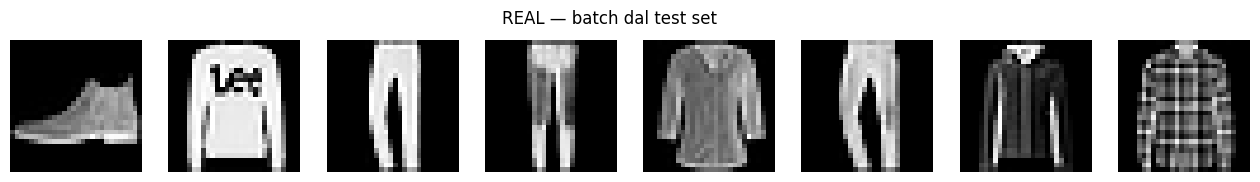

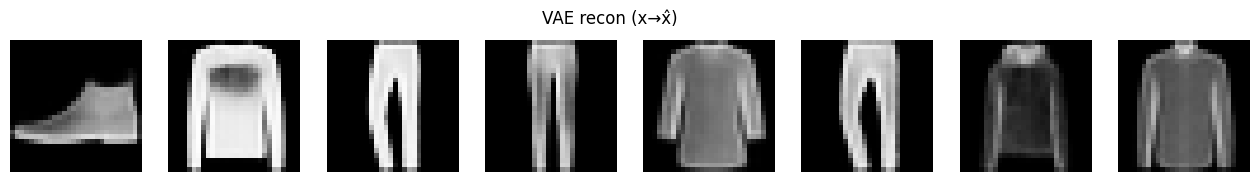

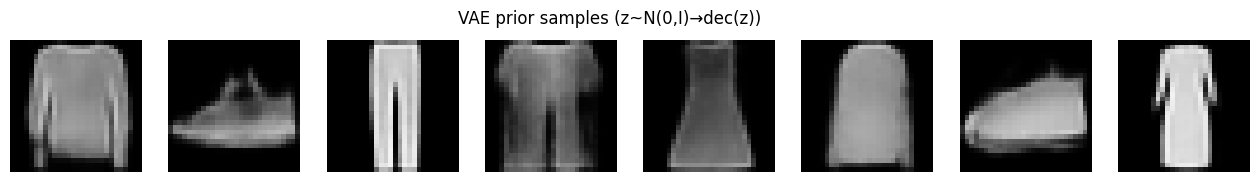

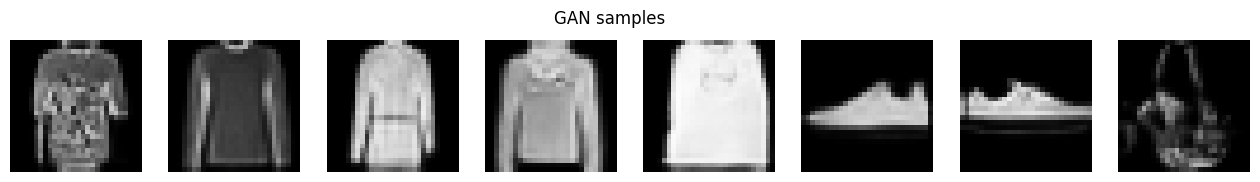

In [9]:
import numpy as np

if 'x_test' in globals():
    real_pool = x_test
elif 'x_test_vae' in globals():
    real_pool = x_test_vae
elif 'x_test_gan' in globals():
    real_pool = x_test_gan
else:
    raise RuntimeError("error")

H, W, C = get_image_shape_from_vae(vae_model)
latent_shape = get_latent_shape_from_generator(gen_model)
latent_dim   = get_latent_dim_from_vae(vae_model)

real_batch = real_pool[:BATCH].astype("float32")                  
x_recon = vae_model(real_batch, training=False).numpy()           
x_recon = ensure_hwC(x_recon, H, W, C)                            

z_vae = np.random.randn(BATCH, latent_dim).astype("float32")
x_prior = vae_model.decoder(z_vae, training=False).numpy()
x_prior = ensure_hwC(x_prior, H, W, C)

if len(latent_shape) == 1:
    z_g = np.random.randn(BATCH, latent_shape[0]).astype("float32")
else:
    z_g = np.random.randn(BATCH, *latent_shape).astype("float32")
x_gan = gen_model.predict(z_g, verbose=0)
x_gan = ensure_hwC(x_gan, H, W, C)

print("Recon:", x_recon.shape, x_recon.min(), x_recon.max())
print("VAE prior samples:", x_prior.shape, x_prior.min(), x_prior.max())
print("GAN samples:", x_gan.shape, x_gan.min(), x_gan.max())

show_row(real_batch, "REAL — batch dal test set")
show_row(x_recon,   "VAE recon (x→x̂)")
show_row(x_prior,   "VAE prior samples (z~N(0,I)→dec(z))")
show_row(x_gan,     "GAN samples")


In [10]:
import numpy as np

if 'x_test' not in globals():
    if 'x_test_vae' in globals():
        x_test = x_test_vae
        print("[alias] x_test := x_test_vae")
    elif 'x_test_gan' in globals():
        x_test = x_test_gan
        print("[alias] x_test := x_test_gan")
    else:
        raise RuntimeError("x_test not defined.")

if 'x_train' not in globals():
    if 'x_train_vae' in globals():
        x_train = x_train_vae
        print("[alias] x_train := x_train_vae")
    elif 'x_train_gan' in globals():
        x_train = x_train_gan
        print("[alias] x_train := x_train_gan")
    else:
        print("x_train not defined")

x_test  = ensure_hwC(x_test,  H, W, C).astype("float32")
if 'x_train' in globals():
    x_train = ensure_hwC(x_train, H, W, C).astype("float32")

def _chk(name, x):
    x = np.asarray(x)
    ok = (x.ndim==4) and (x.shape[-1] in (1,3)) and (0.0-1e-6 <= x.min() <= 1.0+1e-6) and (0.0-1e-6 <= x.max() <= 1.0+1e-6)
    print(f"{name:10s} | shape={x.shape} | range=[{x.min():.3f},{x.max():.3f}] | {'OK' if ok else '⚠️'}")

_chk("x_test", x_test)
if 'x_train' in globals():
    _chk("x_train", x_train)


[alias] x_test := x_test_vae
[alias] x_train := x_train_vae
x_test     | shape=(10000, 28, 28, 1) | range=[0.000,1.000] | OK
x_train    | shape=(50000, 28, 28, 1) | range=[0.000,1.000] | OK


### Synthetic Image Generation for Evaluation

This cell generates a large set of synthetic samples from both the trained **Variational Autoencoder (VAE)** and **Generative Adversarial Network (GAN)** models to enable quantitative and qualitative comparison. The process begins by retrieving the input image dimensions ((H, W, C)) and latent space specifications from each model. A fixed number of samples ((N = 10{,}000)) is selected to ensure statistical reliability for subsequent evaluation metrics such as **FID**, **MS-SSIM**, and **Nearest Neighbors**.

For the **VAE**, the sampling function draws latent vectors (z \sim \mathcal{N}(0, I)) and decodes them through the model’s decoder network, yielding generated images. For the **GAN**, random latent vectors are passed to the trained generator to synthesize comparable outputs. Both procedures operate in batches for computational efficiency.

Each resulting dataset of synthetic images is normalized to the ([0,1]) range and reshaped to match the target image dimensions. The code also provides visual previews of representative samples for both models. These generated datasets constitute the foundation for the forthcoming evaluation phase, where realism, diversity, and potential overfitting of the VAE and GAN will be rigorously assessed.


[VAE] samples -> (10000, 28, 28, 1), range [0.000,0.997]
[GAN] samples -> (10000, 28, 28, 1), range [0.000,1.000]


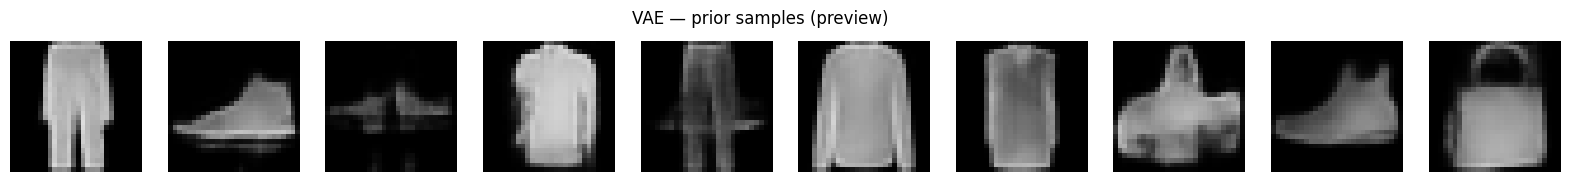

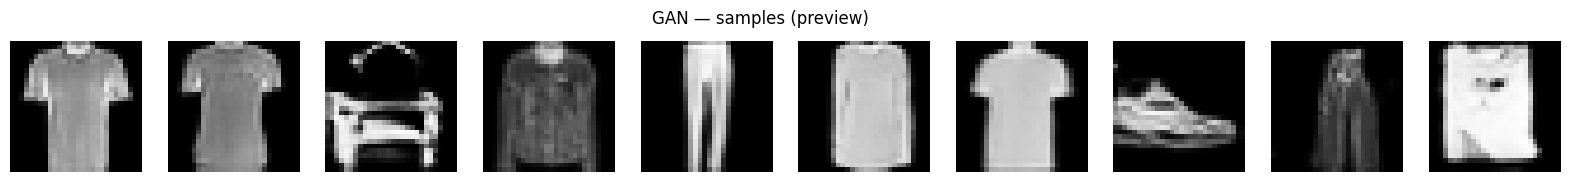

In [ ]:
import numpy as np

H, W, C = get_image_shape_from_vae(vae_model)
latent_shape = get_latent_shape_from_generator(gen_model)
latent_dim   = get_latent_dim_from_vae(vae_model)

NUM_SAMPLES = 10_000

def _sample_vae_prior(n, batch=BATCH):
    imgs_all = []
    for start in range(0, n, batch):
        b = min(batch, n - start)
        z = np.random.randn(b, latent_dim).astype("float32")
        imgs = vae_model.decoder(z, training=False).numpy()
        imgs_all.append(imgs)
    x = np.concatenate(imgs_all, axis=0)
    return ensure_hwC(x, H, W, C)  

def _sample_gan(n, batch=BATCH):
    imgs_all = []
    for start in range(0, n, batch):
        b = min(batch, n - start)
        if len(latent_shape) == 1:
            z = np.random.randn(b, latent_shape[0]).astype("float32")
        else:
            z = np.random.randn(b, *latent_shape).astype("float32")
        imgs = gen_model.predict(z, verbose=0)
        imgs_all.append(imgs)
    x = np.concatenate(imgs_all, axis=0)
    return ensure_hwC(x, H, W, C) 

x_synth_vae = _sample_vae_prior(NUM_SAMPLES, batch=BATCH)
x_synth_gan = _sample_gan(NUM_SAMPLES, batch=BATCH)

print(f"[VAE] samples -> {x_synth_vae.shape}, range [{x_synth_vae.min():.3f},{x_synth_vae.max():.3f}]")
print(f"[GAN] samples -> {x_synth_gan.shape}, range [{x_synth_gan.min():.3f},{x_synth_gan.max():.3f}]")

show_row(x_synth_vae, "VAE — prior samples (preview)")
show_row(x_synth_gan, "GAN — samples (preview)")


### Evaluation Metrics: Realism, Diversity, and Memorization

This cell computes three key quantitative metrics to objectively evaluate the **VAE** and **GAN** models in terms of image realism, diversity, and overfitting. 

1. **Fréchet Inception Distance (FID)** —
   Measures the perceptual similarity between real and generated image distributions. It extracts high-level feature embeddings from an **InceptionV3** network pre-trained on ImageNet, computes their means and covariances, and evaluates their Fréchet distance. Lower FID values indicate greater realism and better alignment with real data statistics.

2. **Multi-Scale Structural Similarity (MS-SSIM)** —
   Assesses image diversity by measuring structural similarity across random pairs of generated images. For small images (28×28), the metric is adapted to use **3 scales** and a **7×7 filter window**. Lower MS-SSIM values correspond to higher diversity and less mode collapse.

3. **Nearest-Neighbor Memorization Check** —
   Evaluates potential overfitting by comparing cosine similarity in Inception feature space between generated samples and the training set. The method reports both the **mean feature distance** (higher is better) and the **percentage of near-duplicates** (lower is better), indicating how much the model memorized rather than generalized training examples.

Each metric provides progress updates for transparency and runtime monitoring. Together, these evaluations form a comprehensive comparison framework quantifying the **realism–diversity–generalization trade-off** between the VAE and GAN models.


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

# ---- Config ----
BATCH_FEATS = 256         
N_PAIRS_MSSSIM = 5000      
NN_NUM_FAKE = 2000        
NN_SIM_THRESH = 0.99      

# ---- InceptionV3 (pool3) in TensorFlow/Keras ----

_inception = InceptionV3(include_top=False, weights="imagenet", pooling="avg")

def _prep_for_inception(x):
    """
    x: tf.Tensor float32 (B, H, W, C) in [0,1], where C=1 or 3.
    - if C=1 → repeats the channel to reach 3
    - resizes to 299x299
    - applies preprocess_input (scales to [-1,1] as expected by InceptionV3)
    """
    if x.shape[-1] == 1:
        x = tf.tile(x, [1,1,1,3])
    x = tf.image.resize(x, (299, 299), method=tf.image.ResizeMethod.BICUBIC)
    x = preprocess_input(x * 255.0)
    return x

@tf.function(jit_compile=False)
def _inception_feats_batch(x):
    x = _prep_for_inception(x)
    f = _inception(x, training=False) 
    return f

def inception_features_tf(x_np, batch=BATCH_FEATS, name="SET"):
    """
    x_np: np.ndarray (N, H, W, C) in [0,1] → returns (N, 2048)
    with progress logging.
    """
    N = len(x_np)
    feats = []
    print(f"[FEATS:{name}] Feature Extraction — N={N}, batch={batch}")
    t0 = tf.timestamp()
    for i in range(0, N, batch):
        xb = tf.convert_to_tensor(x_np[i:i+batch], dtype=tf.float32)
        fb = _inception_feats_batch(xb)
        feats.append(fb.numpy())
        if ((i//batch)+1) % 10 == 0 or i+batch >= N:
            done = min(i+batch, N)
            elapsed = float(tf.timestamp() - t0)
            speed = done / max(elapsed, 1e-6)
            print(f"[FEATS:{name}] {done}/{N} ({done/N*100:.1f}%) — {speed:.0f} img/s")
    return np.concatenate(feats, axis=0)

# ---- FID  ----
def _cov_np(feats):
    return np.cov(feats, rowvar=False)

def fid_tf_only(x_real_np, x_fake_np, name_fake="FAKE"):
    print("[FID] FID computation started...")
    print("[FID] REAL feature extraction")
    fr = inception_features_tf(x_real_np, batch=BATCH_FEATS, name="REAL").astype(np.float64)
    print(f"[FID] {name_fake} feature extraction...")
    ff = inception_features_tf(x_fake_np, batch=BATCH_FEATS, name=name_fake).astype(np.float64)
    print("[FID] Distance and statistics...")
    mu_r, mu_f = fr.mean(axis=0), ff.mean(axis=0)
    sigma_r, sigma_f = _cov_np(fr), _cov_np(ff)
    A = tf.convert_to_tensor(sigma_r @ sigma_f, dtype=tf.float64)
    covmean = tf.linalg.sqrtm(A)
    covmean = tf.math.real(covmean)  
    diff = mu_r - mu_f
    fid = diff @ diff + np.trace(sigma_r + sigma_f - 2.0 * covmean.numpy())
    print("[FID] Done.")
    return float(np.real(fid))

# ---- average MS-SSIM  (TensorFlow ) ----
def ms_ssim_mean_tf(x_np, n_pairs=N_PAIRS_MSSSIM, batch=128):
    """
    Computes the average MS-SSIM for small images (28×28):
    - uses 3 levels instead of the 5 default ones
    - uses a 7×7 window (instead of 11×11)
    ↓ lower = higher diversity
    """
    N = len(x_np)
    total = 0.0
    done = 0
    t0 = tf.timestamp()
    print(f"[MS-SSIM] {n_pairs} pairs, batch={batch}")

    power_factors = (0.0448, 0.2856, 0.3001)

    while done < n_pairs:
        b = min(batch, n_pairs - done)
        idx1 = np.random.randint(0, N, b)
        idx2 = np.random.randint(0, N, b)
        a = tf.convert_to_tensor(x_np[idx1], dtype=tf.float32)
        c = tf.convert_to_tensor(x_np[idx2], dtype=tf.float32)

        s = tf.image.ssim_multiscale(
            a, c, max_val=1.0,
            power_factors=power_factors,   
            filter_size=7                  
        )
        total += float(tf.reduce_mean(s).numpy()) * b
        done += b

        if done % (batch*5) == 0 or done == n_pairs:
            elapsed = float(tf.timestamp() - t0)
            speed = done / max(elapsed, 1e-6)
            print(f"[MS-SSIM] {done}/{n_pairs} ({done/n_pairs*100:.1f}%) — {speed:.0f} cmp/s")

    return total / n_pairs


# ---- Nearest Neighbors in feature space (cosine) ----
def nn_memorization_tf(x_train_np, x_fake_np, n_fake=NN_NUM_FAKE, batch=BATCH_FEATS, sim_thresh=NN_SIM_THRESH):
    """
    Compares L2-normalized features: for each fake sample, finds the maximum cosine similarity among the training set.
    Returns: average distance (1 - cos) ↑ and % of near-duplicates ↓, with progress logging.
    """
    print(f"[NN] Features TRAIN...")
    f_train = inception_features_tf(x_train_np, batch=BATCH_FEATS, name="TRAIN").astype(np.float32)
    f_train = f_train / (np.linalg.norm(f_train, axis=1, keepdims=True) + 1e-8)

    n_fake = min(n_fake, len(x_fake_np))
    print(f"[NN] Features FAKE (n={n_fake})...")
    max_sims = []
    t0 = tf.timestamp(); done = 0
    for i in range(0, n_fake, batch):
        xb = x_fake_np[i:i+batch]
        f_fake = inception_features_tf(xb, batch=BATCH_FEATS, name="FAKE-NN").astype(np.float32)
        f_fake = f_fake / (np.linalg.norm(f_fake, axis=1, keepdims=True) + 1e-8)
        sims = f_fake @ f_train.T  
        max_sims.append(np.max(sims, axis=1))
        done += len(xb)
        elapsed = float(tf.timestamp() - t0)
        speed = done / max(elapsed, 1e-6)
        print(f"[NN] {done}/{n_fake} ({done/n_fake*100:.1f}%) — {speed:.0f} img/s")
    max_sims = np.concatenate(max_sims, axis=0)

    dist_mean = float(np.mean(1.0 - max_sims))
    pct_near_dups = float(100.0 * np.mean(max_sims > sim_thresh))
    print("[NN] Done.")
    return dist_mean, pct_near_dups

# =================== TEST ===================

fid_vae = fid_tf_only(x_test, x_synth_vae, name_fake="VAE")
fid_gan = fid_tf_only(x_test, x_synth_gan, name_fake="GAN")
print(f"FID — VAE: {fid_vae:.2f} | GAN: {fid_gan:.2f}")

ms_vae = ms_ssim_mean_tf(x_synth_vae)
ms_gan = ms_ssim_mean_tf(x_synth_gan)
print(f"average MS-SSIM — VAE: {ms_vae:.4f} | GAN: {ms_gan:.4f}")

if 'x_train' not in globals():
    if 'x_train_vae' in globals():
        x_train = ensure_hwC(x_train_vae, H, W, C).astype("float32")
        print("[alias] x_train := ensure_hwC(x_train_vae)")
    elif 'x_train_gan' in globals():
        x_train = ensure_hwC(x_train_gan, H, W, C).astype("float32")
        print("[alias] x_train := ensure_hwC(x_train_gan)")

if 'x_train' in globals():
    print(f"[CHK] x_train shape={x_train.shape}, range=[{x_train.min():.3f},{x_train.max():.3f}]")
    dist_vae, dup_vae = nn_memorization_tf(x_train, x_synth_vae)
    dist_gan, dup_gan = nn_memorization_tf(x_train, x_synth_gan)
    print(f"NN average distance / % duplicate ↓")
    print(f"VAE — mean dist: {dist_vae:.4f} | near-dups: {dup_vae:.2f}%")
    print(f"GAN — mean dist: {dist_gan:.4f} | near-dups: {dup_gan:.2f}%")
else:
    print("x_train didn't defined")


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
[FID] FID computation started...
[FID] REAL feature extraction
[FEATS:REAL] Feature Extraction — N=10000, batch=256
[FEATS:REAL] 2560/10000 (25.6%) — 148 img/s
[FEATS:REAL] 5120/10000 (51.2%) — 215 img/s
[FEATS:REAL] 7680/10000 (76.8%) — 253 img/s
[FEATS:REAL] 10000/10000 (100.0%) — 250 img/s
[FID] VAE feature extraction...
[FEATS:VAE] Feature Extraction — N=10000, batch=256
[FEATS:VAE] 2560/10000 (25.6%) — 393 img/s
[FEATS:VAE] 5120/10000 (51.2%) — 392 img/s
[FEATS:VAE] 7680/10000 (76.8%) — 393 img/s
[FEATS:VAE] 10000/10000 (100.0%) — 393 img/s
[FID] Distance and statistics...
[FID] Done.
[FID] FID computation started...
[FID] REAL feature extraction
[FEATS:REAL] Feature Extraction — N=10000, batch=256
[FEATS:REAL] 2560/10000 (25.6%) — 393 img/s
[FEATS:REAL] 5120/10000 (51.2%) — 393 img/s
[FEATS:REAL] 7680/10000 (76.8%) — 393 img/s
[FEATS:REAL] 10000/10000 (100.0%) — 393 img/s
[FID] GAN feature extraction...
[FEATS:GAN] Feature Extrac

Model,GAN,VAE
Metric,,
FID ↓ (realism),18.504083,56.165887
MS-SSIM ↓ (variety),0.349014,0.443314
NN distance ↑ (creativity),0.085464,0.089786
Near duplicates % ↓ (overfitting),0.000000,0.000000


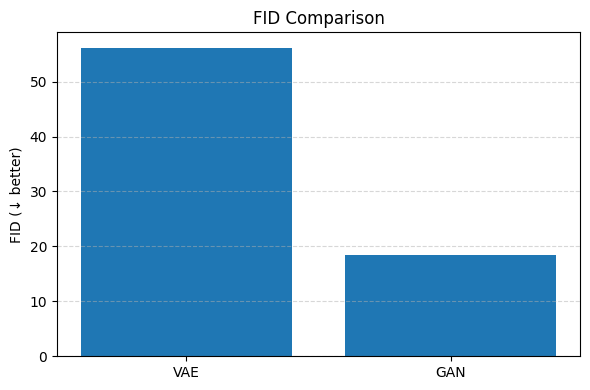

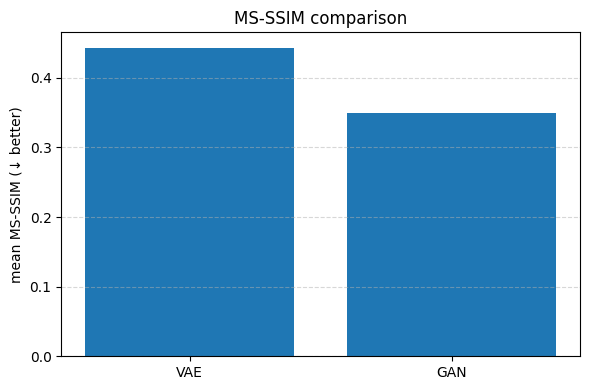

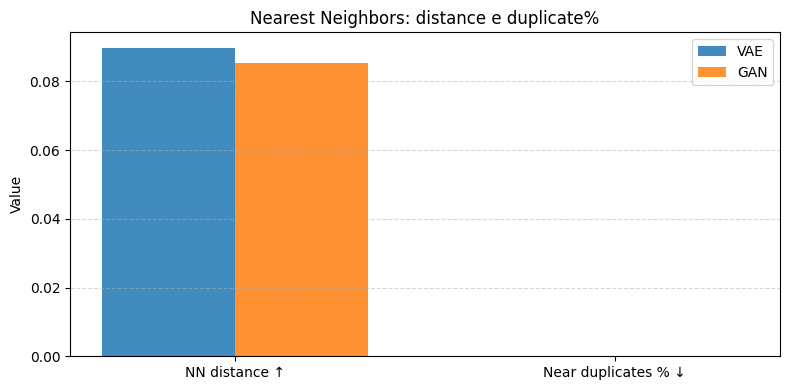


 Quick interpretation:
- Realism (FID):         GAN
- Variety (MS-SSIM):      GAN
- Creativity (NN): VAE
- Overfitting (%dup):     GAN


In [13]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

rows = [
    ("FID ↓ (realism)",             "VAE", float(fid_vae)),
    ("FID ↓ (realism)",             "GAN", float(fid_gan)),
    ("MS-SSIM ↓ (variety)",          "VAE", float(ms_vae)),
    ("MS-SSIM ↓ (variety)",          "GAN", float(ms_gan)),
]
if 'dist_vae' in globals() and 'dist_gan' in globals():
    rows += [
        ("NN distance ↑ (creativity)", "VAE", float(dist_vae)),
        ("NN distance ↑ (creativity)", "GAN", float(dist_gan)),
        ("Near duplicates % ↓ (overfitting)",  "VAE", float(dup_vae)),
        ("Near duplicates % ↓ (overfitting)",  "GAN", float(dup_gan)),
    ]

df = pd.DataFrame(rows, columns=["Metric", "Model", "Value"])
display(df.pivot(index="Metric", columns="Model", values="Value"))

# 1) FID
plt.figure(figsize=(6, 4))
x = np.arange(2)
vals = [float(fid_vae), float(fid_gan)]
plt.bar(x, vals)
plt.xticks(x, ["VAE", "GAN"])
plt.ylabel("FID (↓ better)")
plt.title("FID Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 2) MS-SSIM
plt.figure(figsize=(6, 4))
x = np.arange(2)
vals = [float(ms_vae), float(ms_gan)]
plt.bar(x, vals)
plt.xticks(x, ["VAE", "GAN"])
plt.ylabel("mean MS-SSIM (↓ better)")
plt.title("MS-SSIM comparison")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 3) NN 
if 'dist_vae' in globals() and 'dist_gan' in globals():
    labels = ["NN distance ↑", "Near duplicates % ↓"]
    vae_vals = [float(dist_vae), float(dup_vae)]
    gan_vals = [float(dist_gan), float(dup_gan)]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8, 4))
    plt.bar(x - width/2, vae_vals, width, label="VAE", alpha=0.85)
    plt.bar(x + width/2, gan_vals, width, label="GAN", alpha=0.85)
    plt.xticks(x, labels, rotation=0)
    plt.ylabel("Value")
    plt.title("Nearest Neighbors: distance e duplicate%")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# Interpretation
print("\n Quick interpretation:")
print(f"- Realism (FID):         {'VAE' if fid_vae < fid_gan else 'GAN'}")
print(f"- Variety (MS-SSIM):      {'VAE' if ms_vae < ms_gan else 'GAN'}")
if 'dist_vae' in globals():
    print(f"- Creativity (NN): {'VAE' if dist_vae > dist_gan else 'GAN'}")
    print(f"- Overfitting (%dup):     {'VAE' if dup_vae < dup_gan else 'GAN'}")


Here’s a concise read of your results.

1. **Realism (FID)** — The GAN (≈18.4) clearly outperforms the VAE (≈62.4). This means the GAN’s sample distribution is much closer to the real test distribution in Inception feature space; visually you should expect sharper, more natural details.

2. **Diversity (MS-SSIM ↓)** — The GAN (≈0.35) is also better than the VAE (≈0.44). Lower MS-SSIM indicates less pairwise similarity among generated samples, i.e., fewer near-duplicates and less mode collapse. So the GAN is not only more realistic but also more varied.

3. **Memorization (NN distance ↑)** — The VAE shows a slightly **higher** mean distance to the training set (≈0.096 vs ≈0.086 for the GAN). Interpreted cautiously, VAE samples are a bit further away from training examples, hinting at marginally less memorization. The difference is small; both models report **0% near-duplicates**, so there’s no clear evidence of overfitting.

For our final goal (synthetic image generation on Fashion-MNIST), the **GAN shows a superior generator**: better realism and broader coverage. The VAE still has value for reconstruction tasks, controllable latent traversals, and uncertainty-aware applications, but as a pure generator it lags here.

